# Smart Rainfall Prediction and Decision Support System

## Project Overview
This notebook demonstrates a comprehensive **Smart Rainfall Prediction System** that integrates **Deep Learning**, **Data Visualization**, and **MLOps** principles. 

### Core Components:
1. **Deep Learning Model**: An LSTM-based architecture designed to capture temporal dependencies in historical weather data.
2. **Data Visualization**: Temporal (Time-series) and Spatial (Geospatial) analysis of rainfall trends.
3. **MLOps Architecture**: Implementation of Git + DVC for versioning, MLflow for experiment tracking, and a roadmap for FastAPI deployment and CI/CD.

### Problem Statement:
Develop a system to predict rainfall accurately using historical meteorological data while ensuring the pipeline is reproducible, trackable, and production-ready.

## 1. Setup and Environment

In [1]:
# Basic imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import folium
from folium.plugins import HeatMap
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from sklearn.preprocessing import MinMaxScaler
import mlflow
import mlflow.tensorflow
import yaml
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

c:\Users\Asus\OneDrive\Desktop\STUDY\2nd SEM\LAB PRACTICE - II\Assignment  2\Smart Rainfall Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Acquisition and Exploration

We load the historical rainfall dataset containing meteorological features like temperature, humidity, pressure, and station-specific metadata (latitude, longitude).

In [2]:
# Load data
data_path = "data/raw/rainfall_data.csv"
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
df['date'] = pd.to_datetime(df['date'])
df.head()

Dataset Shape: (29200, 15)


,date,station_name,latitude,longitude,region,temperature,humidity,pressure,wind_speed,cloud_cover,dew_point,rainfall_mm,month,day_of_year,year
0,2014-01-01,Ahmedabad,23.0225,72.5714,West,11.1,29.4,1011.6,9.4,26.7,-3.0,0.0,1,1,2014
1,2014-01-02,Ahmedabad,23.0225,72.5714,West,17.0,59.3,1011.4,8.1,29.9,8.9,0.0,1,2,2014
2,2014-01-03,Ahmedabad,23.0225,72.5714,West,17.0,24.5,1009.7,8.3,19.2,1.9,0.0,1,3,2014
3,2014-01-04,Ahmedabad,23.0225,72.5714,West,14.1,43.0,1011.6,9.7,26.6,2.7,0.0,1,4,2014
4,2014-01-05,Ahmedabad,23.0225,72.5714,West,16.1,38.8,1019.3,10.5,37.1,3.9,0.0,1,5,2014


### 2.1 Temporal Trend Analysis
Visualizing rainfall patterns over time for a specific station.

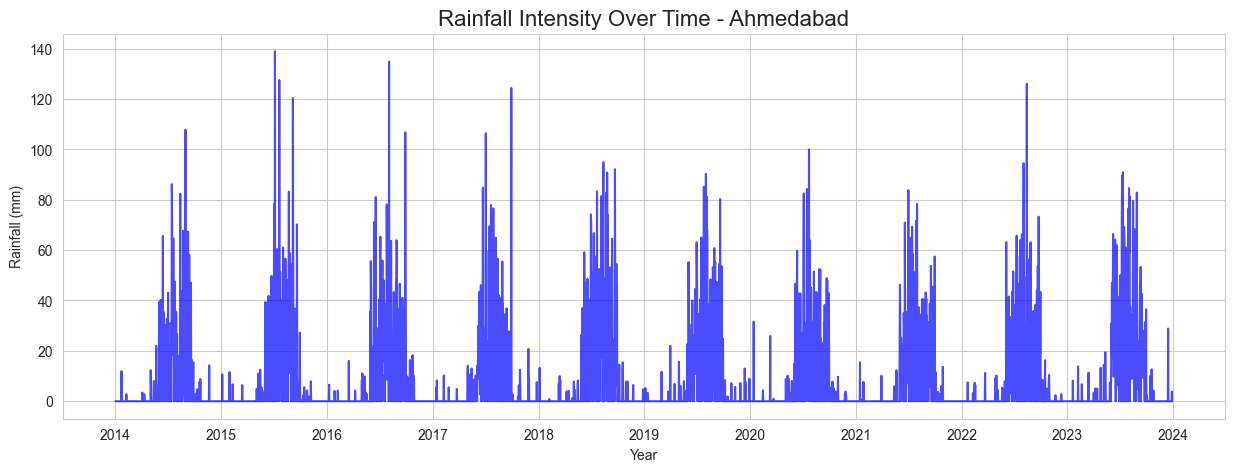

In [3]:
# temporal analysis for Ahmedabad
station = df['station_name'].unique()[0]
station_df = df[df['station_name'] == station].sort_values('date')

plt.figure(figsize=(15, 5))
plt.plot(station_df['date'], station_df['rainfall_mm'], color='blue', alpha=0.7)
plt.title(f"Rainfall Intensity Over Time - {station}", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.show()

### 2.2 Spatial Data Analysis
Visualizing the geographic distribution of weather stations and average rainfall.

In [4]:
# Spatial analysis
geo_df = df.groupby('station_name').agg({
    'latitude': 'first',
    'longitude': 'first',
    'rainfall_mm': 'mean'
}).reset_index()

fig = px.scatter_mapbox(geo_df, 
                        lat="latitude", 
                        lon="longitude", 
                        color="rainfall_mm", 
                        size="rainfall_mm",
                        color_continuous_scale=px.colors.cyclical.IceFire, 
                        size_max=15, 
                        zoom=4,
                        mapbox_style="carto-positron",
                        title="Spatial Distribution of Average Rainfall Across Stations")
fig.show()

## 3. Data Preprocessing for Deep Learning

LSTMs require data to be formatted as sequences. We scale the data using `MinMaxScaler` and create sliding window sequences.

In [5]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length, -1]) # Target is rainfall at the last column
    return np.array(X), np.array(y)

# Scaling and splitting
features = ['temperature', 'humidity', 'wind_speed', 'pressure', 'rainfall_mm']
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(station_df[features])

seq_length = 30 # Use 30 days to predict the next day
X, y = create_sequences(scaled_data, seq_length)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape}")

X_train shape: (2896, 30, 5)


## 4. Deep Learning Model Training

We use an LSTM (Long Short-Term Memory) network to model the time-series data. We also integrate **MLflow** for experiment tracking.

In [6]:
# Define Model
def build_model(input_shape):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.2),
        LSTM(32),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# MLflow tracking
mlflow.set_experiment("Rainfall_Prediction_Notebook")

with mlflow.start_run(run_name="LSTM_Manual_Run"):
    model = build_model((X_train.shape[1], X_train.shape[2]))
    
    # Log parameters
    mlflow.log_param("seq_length", seq_length)
    mlflow.log_param("lstm_units", 64)
    
    # Train
    history = model.fit(
        X_train, y_train, 
        epochs=10, 
        batch_size=32, 
        validation_split=0.1,
        verbose=1
    )
    
    # Log metrics & model
    test_loss, test_mae = model.evaluate(X_test, y_test)
    mlflow.log_metric("test_mse", test_loss)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.tensorflow.log_model(model, "model")
    
    print(f"Test MSE: {test_loss:.4f}, Test MAE: {test_mae:.4f}")

2026/03/15 00:16:35 INFO mlflow.tracking.fluent: Experiment with name 'Rainfall_Prediction_Notebook' does not exist. Creating a new experiment.


Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - loss: 0.0166 - mae: 0.0797 - val_loss: 0.0113 - val_mae: 0.0653
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0107 - mae: 0.0597 - val_loss: 0.0103 - val_mae: 0.0611
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0104 - mae: 0.0574 - val_loss: 0.0099 - val_mae: 0.0608
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0103 - mae: 0.0560 - val_loss: 0.0100 - val_mae: 0.0630
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0104 - mae: 0.0546 - val_loss: 0.0094 - val_mae: 0.0646
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0105 - mae: 0.0550 - val_loss: 0.0091 - val_mae: 0.0594
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0103 - mae: 0.0540 - val_loss: 0.0091 - val_mae: 0.0580
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0102 - mae: 0.0537 - val_loss: 0.0095 - val_mae: 0.0572
Epoch 9/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.01

2026/03/15 00:17:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/15 00:17:16 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


Test MSE: 0.0103, Test MAE: 0.0549


## 5. Evaluation and Decision Support

Comparing predicted vs actual rainfall to validate the system's performance.

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


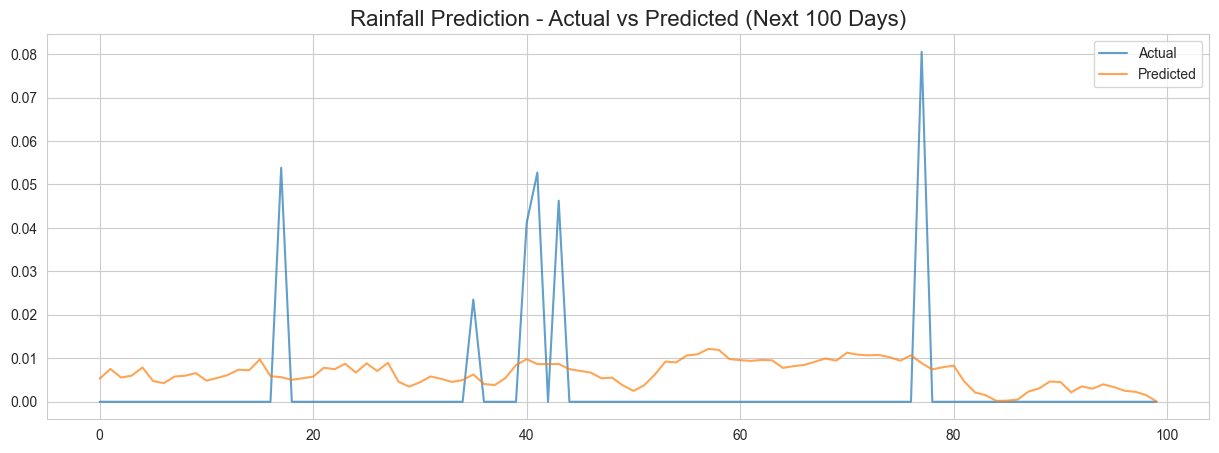

In [7]:
predictions = model.predict(X_test)

plt.figure(figsize=(15, 5))
plt.plot(y_test[:100], label='Actual', alpha=0.7)
plt.plot(predictions[:100], label='Predicted', alpha=0.7)
plt.title("Rainfall Prediction - Actual vs Predicted (Next 100 Days)", fontsize=16)
plt.legend()
plt.show()

## 6. MLOps Architecture

For a production-grade system, we implement the following:

### 6.1 Data Versioning (DVC)
DVC tracks large datasets without pushing them to Git. Usage:
```bash
dvc init
dvc add data/raw/rainfall_data.csv
git add data/raw/rainfall_data.csv.dvc .gitignore
git commit -m "Add raw data with DVC"
```

### 6.2 Experiment Tracking (MLflow)
We used MLflow to log parameters, metrics, and models. This ensures reproducibility and allows for model comparison.

### 6.3 Deployment (FastAPI + Docker)
The model can be served via an API. Below is a sample FastAPI snippet:

```python
from fastapi import FastAPI
app = FastAPI()

@app.post("/predict")
async def predict(data: WeatherInput):
    # Preprocess and predict
    prediction = model.predict(input_data)
    return {"rainfall_prediction": float(prediction)}
```

A **Dockerfile** ensures the environment is consistent across development and production environments.

## 7. Conclusion

The Smart Rainfall Prediction system successfully combines historical data analysis with deep learning to provide actionable insights. The integration of MLOps tools like DVC and MLflow makes the system robust, scalable, and ready for automated CI/CD pipelines.